# 국립중앙박물관 유료입장 전환 시 최적 입장료 분석
## Step 1: K-means 클러스터링 + 다중회귀분석

**목적**: 세계 주요 박물관 데이터를 기반으로 국립중앙박물관의 적정 입장료를 추정한다.

**분석 흐름**:
1. 데이터 로드 및 병합
2. K-means 클러스터링 → 비교 그룹 도출
3. 다중회귀분석 → 적정 입장료 예측
4. 종합 가격 추정

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'    # Mac
# plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# 데이터 경로 (프로젝트 루트 기준 ../data/)
DATA_DIR = '../data/'
OUTPUT_DIR = '../output/'

## 1. 데이터 로드 및 병합

In [2]:
# CSV 로드
info = pd.read_csv(f'{DATA_DIR}museum_info.csv')
city = pd.read_csv(f'{DATA_DIR}museum_city.csv')
financial = pd.read_csv(f'{DATA_DIR}museum_financial.csv')
visitor = pd.read_csv(f'{DATA_DIR}museum_visitor.csv')

print(f'museum_info: {info.shape}')
print(f'museum_city: {city.shape}')
print(f'museum_financial: {financial.shape}')
print(f'museum_visitor: {visitor.shape}')

museum_info: (21, 15)
museum_city: (15, 7)
museum_financial: (21, 10)
museum_visitor: (145, 7)


In [3]:
# visitor에서 박물관별 가장 최신 연도 방문객 수 추출
visitor['total_clean'] = visitor['total'].astype(str).str.replace(',', '').astype(float)

latest_visitors = (
    visitor
    .sort_values('year', ascending=False)
    .groupby('museum_id')
    .first()
    .reset_index()[['museum_id', 'total_clean', 'year']]
    .rename(columns={'museum_id': 'id', 'total_clean': 'visitors_latest', 'year': 'visitor_year'})
)

print(f'최신 방문객 데이터: {len(latest_visitors)}개 박물관')
latest_visitors

최신 방문객 데이터: 21개 박물관


,id,visitors_latest,visitor_year
0,1001.0,8737050.0,2024
1,1002.0,6825436.0,2024
2,1003.0,6479952.0,2024
3,1004.0,5727258.0,2024
4,1005.0,4603025.0,2024
5,1006.0,4234046.0,2024
6,1007.0,3936543.0,2024
7,1008.0,3788785.0,2024
8,1009.0,3751141.0,2024
9,1010.0,3700000.0,2024


In [4]:
# 3개 테이블 조인
df = info.merge(city, on='city', how='left')
df = df.merge(latest_visitors, on='id', how='left')

print(f'병합 결과: {df.shape[0]}개 박물관, {df.shape[1]}개 컬럼')
print(f'\n결측치 현황:')
for col in ['total_area_sqm', 'collection_size', 'visitors_latest', 'city_gdp_per_capita', 'big_mac_index']:
    print(f'  {col}: {df[col].isna().sum()}/{len(df)}')

df[['museum', 'total_area_sqm', 'collection_size', 'adult_price_local_usd', 
    'visitors_latest', 'city_gdp_per_capita']].head(21)

병합 결과: 21개 박물관, 23개 컬럼

결측치 현황:
  total_area_sqm: 0/21
  collection_size: 0/21
  visitors_latest: 0/21
  city_gdp_per_capita: 0/21
  big_mac_index: 0/21


,museum,total_area_sqm,collection_size,adult_price_local_usd,visitors_latest,city_gdp_per_capita
0,Musée du Louvre,758000.0,615797.0,25.52,8737050.0,85000
1,Vatican Museums,55000.0,70000.0,23.20,6825436.0,38000
2,British Museum,92000.0,8000000.0,0.00,6479952.0,80000
3,Metropolitan Museum of Art,200000.0,2000000.0,30.00,5727258.0,100000
4,Tate Modern,34500.0,70000.0,0.00,4603025.0,80000
5,Shanghai Museum East,113000.0,147044.0,0.00,4234046.0,27000
6,National Gallery of Art,120000.0,150000.0,0.00,3936543.0,95000
7,National Museum of Korea,146766.0,420000.0,0.00,3788785.0,45000
8,Musée d'Orsay,57400.0,150000.0,18.56,3751141.0,85000
9,Museo Nacional de Antropología,45000.0,600000.0,5.40,3700000.0,25000


## 2. K-means 클러스터링

국립중앙박물관과 유사한 박물관 그룹을 찾아, 같은 그룹 유료 박물관의 입장료를 벤치마크로 활용한다.

**사용 피처**: 면적, 소장품 수, 입장료, 방문객 수, 도시 인구, 도시 1인당 GDP

In [5]:
# 클러스터링 피처 선택
cluster_features = [
    'total_area_sqm',        # 박물관 규모
    'collection_size',       # 소장품 수 (콘텐츠 규모)
    'adult_price_local_usd', # 현재 입장료
    'visitors_latest',       # 방문객 수 (수요)
    'city_population',       # 도시 규모
    'city_gdp_per_capita',   # 도시 경제 수준
]

X = df[cluster_features].copy()

# 표준화 (K-means는 거리 기반 → 스케일 통일 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('피처 기초 통계:')
X.describe().round(1)

피처 기초 통계:


,total_area_sqm,collection_size,adult_price_local_usd,visitors_latest,city_population,city_gdp_per_capita
count,21.0,21.0,21.0,21.0,21.0,21.0
mean,109682.5,1482363.9,9.0,3828239.5,6656942.9,58952.4
std,159734.5,3016570.0,10.9,1878227.1,5825618.0,27211.2
min,10000.0,2300.0,0.0,1036689.0,800.0,20000.0
25%,40000.0,70000.0,0.0,2657377.0,2161000.0,38000.0
50%,55000.0,200000.0,5.4,3611899.0,8300000.0,50000.0
75%,113000.0,800000.0,17.4,4234046.0,8800000.0,80000.0
max,758000.0,12000000.0,30.0,8737050.0,24900000.0,100000.0


### 2-1. 최적 k 탐색: Elbow + Silhouette

In [6]:
k_range = range(2, 8)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    print(f'k={k}: Inertia={km.inertia_:.1f}, Silhouette={sil:.3f}')

best_k = list(k_range)[np.argmax(silhouettes)]
print(f'\n▶ 최적 k (실루엣 기준): {best_k}')

k=2: Inertia=94.3, Silhouette=0.270
k=3: Inertia=74.1, Silhouette=0.292
k=4: Inertia=55.7, Silhouette=0.260
k=5: Inertia=44.4, Silhouette=0.209
k=6: Inertia=34.6, Silhouette=0.209
k=7: Inertia=29.3, Silhouette=0.182

▶ 최적 k (실루엣 기준): 3


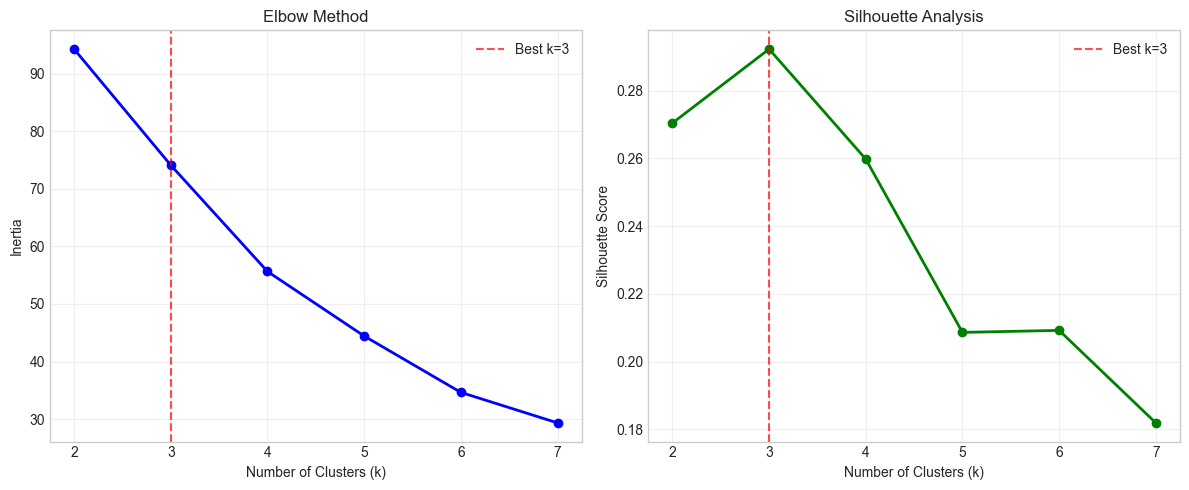

In [7]:
# Elbow + Silhouette 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(list(k_range), inertias, 'bo-', linewidth=2)
ax1.axvline(x=best_k, color='r', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), silhouettes, 'go-', linewidth=2)
ax2.axvline(x=best_k, color='r', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}figures/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

### 2-2. 최종 클러스터링 실행

In [8]:
# 최적 k로 클러스터링
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

# 클러스터별 요약
for c in sorted(df['cluster'].unique()):
    members = df[df['cluster'] == c]
    print(f'\n--- Cluster {c} ({len(members)}개) ---')
    print(f'  박물관: {members["museum"].tolist()}')
    print(f'  평균 입장료: ${members["adult_price_local_usd"].mean():.1f}')
    print(f'  평균 방문객: {members["visitors_latest"].mean():,.0f}')
    print(f'  평균 면적: {members["total_area_sqm"].mean():,.0f} sqm')
    print(f'  평균 도시 GDP: ${members["city_gdp_per_capita"].mean():,.0f}')

nmk_cluster = df.loc[df['museum'] == 'National Museum of Korea', 'cluster'].values[0]
print(f'\n▶ 국립중앙박물관 → Cluster {nmk_cluster}')


--- Cluster 0 (5개) ---
  박물관: ['Musée du Louvre', 'Vatican Museums', 'Metropolitan Museum of Art', "Musée d'Orsay", 'Museum of Modern Art (MoMA)']
  평균 입장료: $25.5
  평균 방문객: 5,539,652
  평균 면적: 227,240 sqm
  평균 도시 GDP: $81,600

--- Cluster 1 (14개) ---
  박물관: ['Tate Modern', 'Shanghai Museum East', 'National Gallery of Art', 'National Museum of Korea', 'Museo Nacional de Antropología', 'State Russian Museum', 'State Hermitage Museum', 'Victoria and Albert Museum', 'Museo Nacional del Prado', 'Tokyo National Museum', 'MMCA Seoul', 'Museum of New Zealand Te Papa Tongarewa', 'Museo Egizio', 'National Gallery']
  평균 입장료: $4.3
  평균 방문객: 3,135,703
  평균 면적: 75,652 sqm
  평균 도시 GDP: $50,000

--- Cluster 2 (2개) ---
  박물관: ['British Museum', 'National Museum of Scotland']
  평균 입장료: $0.0
  평균 방문객: 4,397,463
  평균 면적: 54,000 sqm
  평균 도시 GDP: $65,000

▶ 국립중앙박물관 → Cluster 1


### 2-3. PCA 2D 시각화

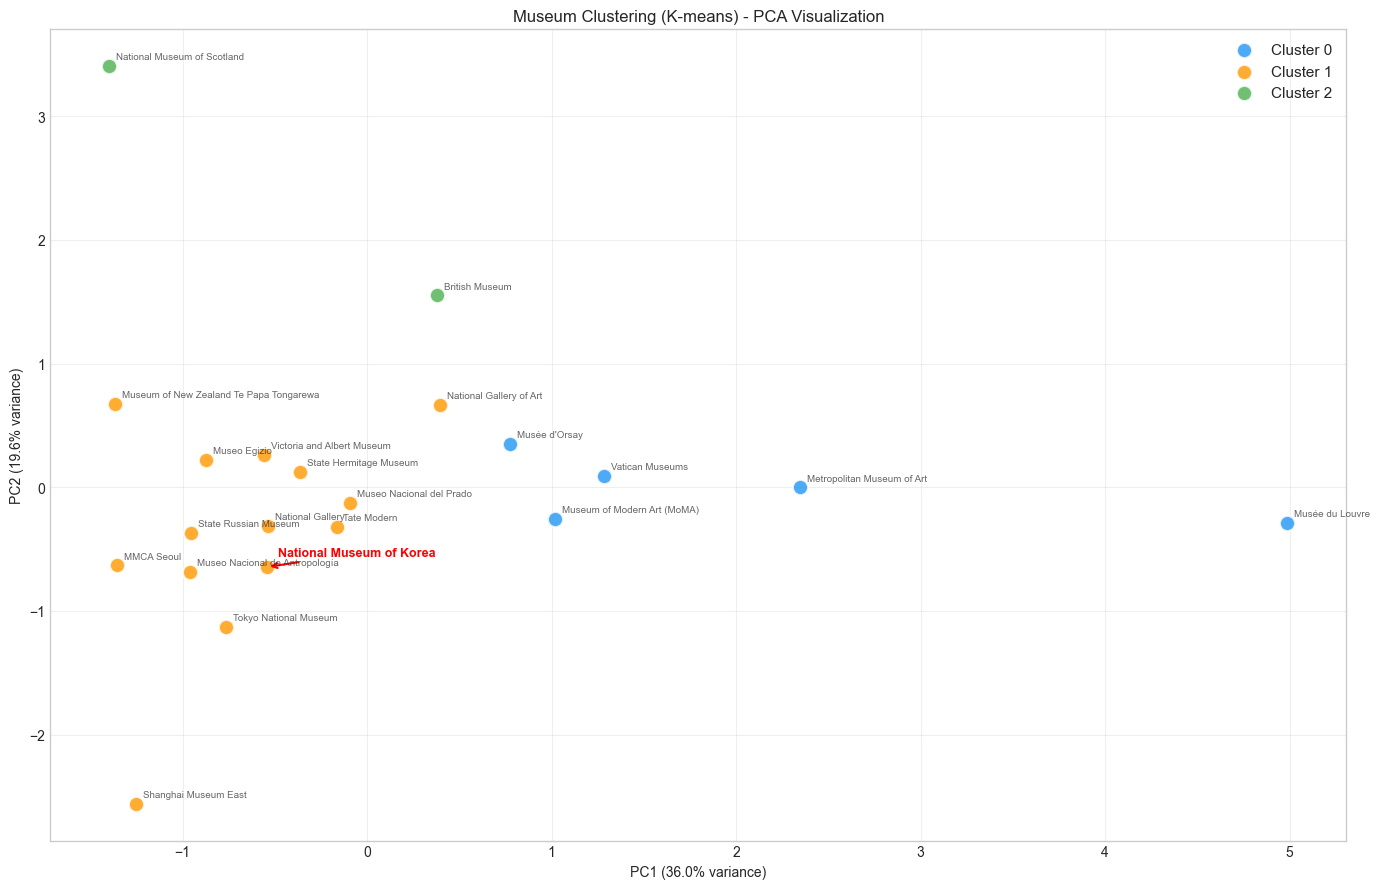

PCA 설명력: PC1=36.0%, PC2=19.6%, 합계=55.7%


In [9]:
# PCA로 2차원 축소
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df['pca1'] = pca_result[:, 0]
df['pca2'] = pca_result[:, 1]

plt.figure(figsize=(14, 9))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']

for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    plt.scatter(df.loc[mask, 'pca1'], df.loc[mask, 'pca2'],
                c=colors[c], s=120, alpha=0.8, edgecolors='white',
                linewidth=1.5, label=f'Cluster {c}', zorder=3)

# 라벨
for _, row in df.iterrows():
    if row['museum'] == 'National Museum of Korea':
        plt.annotate(row['museum'], (row['pca1'], row['pca2']),
                     fontsize=9, fontweight='bold', color='red',
                     xytext=(8, 8), textcoords='offset points',
                     arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    else:
        plt.annotate(row['museum'], (row['pca1'], row['pca2']),
                     fontsize=7, alpha=0.7,
                     xytext=(5, 5), textcoords='offset points')

explained = pca.explained_variance_ratio_
plt.xlabel(f'PC1 ({explained[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained[1]:.1%} variance)')
plt.title('Museum Clustering (K-means) - PCA Visualization')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}figures/kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PCA 설명력: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, 합계={sum(explained):.1%}')

### 2-4. 국립중앙박물관 클러스터 심층 분석

In [10]:
# 국립중앙박물관이 속한 클러스터에서 무료/유료 비교
nmk_cluster = df.loc[df['museum'] == 'National Museum of Korea', 'cluster'].values[0]
cluster_members = df[df['cluster'] == nmk_cluster]

c_free = cluster_members[cluster_members['adult_price_local_usd'] == 0]
c_paid = cluster_members[cluster_members['adult_price_local_usd'] > 0]

print(f'=== Cluster {nmk_cluster} 상세 (국립중앙박물관 소속) ===')
print(f'\n무료 박물관 ({len(c_free)}개):')
for _, r in c_free.iterrows():
    print(f'  {r["museum"]}: 방문객 {r["visitors_latest"]:,.0f}')

print(f'\n유료 박물관 ({len(c_paid)}개):')
for _, r in c_paid.iterrows():
    print(f'  {r["museum"]}: ${r["adult_price_local_usd"]:.1f}, 방문객 {r["visitors_latest"]:,.0f}')

if len(c_paid) > 0:
    print(f'\n유료 박물관 입장료 통계:')
    print(f'  평균: ${c_paid["adult_price_local_usd"].mean():.1f} (₩{c_paid["adult_price_local_usd"].mean()*1472:,.0f})')
    print(f'  중간값: ${c_paid["adult_price_local_usd"].median():.1f} (₩{c_paid["adult_price_local_usd"].median()*1472:,.0f})')
    print(f'  범위: ${c_paid["adult_price_local_usd"].min():.1f} ~ ${c_paid["adult_price_local_usd"].max():.1f}')

=== Cluster 1 상세 (국립중앙박물관 소속) ===

무료 박물관 (7개):
  Tate Modern: 방문객 4,603,025
  Shanghai Museum East: 방문객 4,234,046
  National Gallery of Art: 방문객 3,936,543
  National Museum of Korea: 방문객 3,788,785
  Victoria and Albert Museum: 방문객 3,525,700
  Museum of New Zealand Te Papa Tongarewa: 방문객 1,146,854
  National Gallery: 방문객 3,203,451

유료 박물관 (7개):
  Museo Nacional de Antropología: $5.4, 방문객 3,700,000
  State Russian Museum: $5.5, 방문객 3,611,899
  State Hermitage Museum: $5.5, 방문객 3,563,590
  Museo Nacional del Prado: $17.4, 방문객 3,457,057
  Tokyo National Museum: $6.6, 방문객 2,436,368
  MMCA Seoul: $3.0, 방문객 1,655,834
  Museo Egizio: $17.4, 방문객 1,036,689

유료 박물관 입장료 통계:
  평균: $8.7 (₩12,779)
  중간값: $5.5 (₩8,096)
  범위: $3.0 ~ $17.4


## 3. 다중회귀분석: 입장료 예측

유료 박물관 데이터만으로 회귀 모델을 학습하고, 국립중앙박물관이 **유료로 전환한다면** 얼마를 받아야 하는지 예측한다.

**주의**: 면적(total_area_sqm) 이상치 보정을 위해 로그 변환 적용

In [11]:
# 유료 박물관만 학습 데이터로 사용
paid = df[df['adult_price_local_usd'] > 0].copy()
print(f'학습 데이터: 유료 박물관 {len(paid)}개')
print(f'{paid["museum"].tolist()}')

# 로그 변환 (이상치 보정)
# 루브르(758,000㎡) 등 초대형 박물관이 면적 변수를 왜곡하지 않도록
# 모든 연속형 규모 변수에 로그 변환 적용
log_cols = ['collection_size', 'visitors_latest', 'city_gdp_per_capita']

for f in log_cols:
    paid[f'log_{f}'] = np.log1p(paid[f])
    df[f'log_{f}'] = np.log1p(df[f])

# 회귀 피처
reg_features = [
    'log_collection_size',      # 로그(소장품) - 콘텐츠 가치
    'log_visitors_latest',      # 로그(방문객) - 수요
    'log_city_gdp_per_capita',  # 로그(도시GDP) - 구매력
    'big_mac_index',            # 빅맥지수 - 물가 수준
]

X_train = paid[reg_features]
y_train = paid['adult_price_local_usd']

학습 데이터: 유료 박물관 12개
['Musée du Louvre', 'Vatican Museums', 'Metropolitan Museum of Art', "Musée d'Orsay", 'Museo Nacional de Antropología', 'State Russian Museum', 'State Hermitage Museum', 'Museo Nacional del Prado', 'Tokyo National Museum', 'MMCA Seoul', 'Museo Egizio', 'Museum of Modern Art (MoMA)']


In [12]:
# 회귀 모델 학습
reg = LinearRegression()
reg.fit(X_train, y_train)

r_squared = reg.score(X_train, y_train)
print(f'R² = {r_squared:.3f} (설명력 {r_squared:.1%})')
print(f'\n원본 계수:')
for feat, coef in zip(reg_features, reg.coef_):
    print(f'  {feat}: {coef:.4f}')
print(f'  intercept: {reg.intercept_:.3f}')

# 표준화 계수 (피처 중요도 비교용)
scaler_reg = StandardScaler()
reg_std = LinearRegression()
reg_std.fit(scaler_reg.fit_transform(X_train), y_train)

print(f'\n피처 중요도 (표준화 계수):')
feat_imp = sorted(zip(reg_features, reg_std.coef_), key=lambda x: abs(x[1]), reverse=True)
for feat, coef in feat_imp:
    direction = '↑ 가격 상승' if coef > 0 else '↓ 가격 하락'
    print(f'  {feat:30s} {coef:+.3f}  {direction}')

R² = 0.767 (설명력 76.7%)

원본 계수:
  log_collection_size: 1.1033
  log_visitors_latest: 1.4745
  log_city_gdp_per_capita: 8.6644
  big_mac_index: 2.3425
  intercept: -125.969

피처 중요도 (표준화 계수):
  log_city_gdp_per_capita        +4.903  ↑ 가격 상승
  big_mac_index                  +4.393  ↑ 가격 상승
  log_collection_size            +1.800  ↑ 가격 상승
  log_visitors_latest            +0.827  ↑ 가격 상승


In [13]:
# 전체 박물관에 대해 예측
predictions = reg.predict(df[reg_features])
df['predicted_price_usd'] = np.maximum(predictions, 0)

print('=== 전체 박물관: 실제 vs 예측 입장료 ===')
for _, r in df.sort_values('predicted_price_usd', ascending=False).iterrows():
    actual = f'${r["adult_price_local_usd"]:.1f}' if r['adult_price_local_usd'] > 0 else 'FREE'
    marker = ' ◀◀◀' if r['museum'] == 'National Museum of Korea' else ''
    print(f'  {r["museum"][:38]:38s} 현재: {actual:8s} → 예측: ${r["predicted_price_usd"]:.1f}{marker}')

=== 전체 박물관: 실제 vs 예측 입장료 ===
  British Museum                         현재: FREE     → 예측: $29.1
  Musée du Louvre                        현재: $25.5    → 예측: $28.4
  Metropolitan Museum of Art             현재: $30.0    → 예측: $27.0
  Victoria and Albert Museum             현재: FREE     → 예측: $26.8
  Musée d'Orsay                          현재: $18.6    → 예측: $25.6
  National Museum of Scotland            현재: FREE     → 예측: $23.9
  Museum of Modern Art (MoMA)            현재: $30.0    → 예측: $23.3
  Tate Modern                            현재: FREE     → 예측: $23.3
  National Gallery of Art                현재: FREE     → 예측: $23.1
  National Gallery                       현재: FREE     → 예측: $19.0
  Vatican Museums                        현재: $23.2    → 예측: $17.2
  Museum of New Zealand Te Papa Tongarew 현재: FREE     → 예측: $15.6
  Museo Nacional del Prado               현재: $17.4    → 예측: $15.4
  Museo Egizio                           현재: $17.4    → 예측: $13.8
  Museo Nacional de Antropología         현재: $5

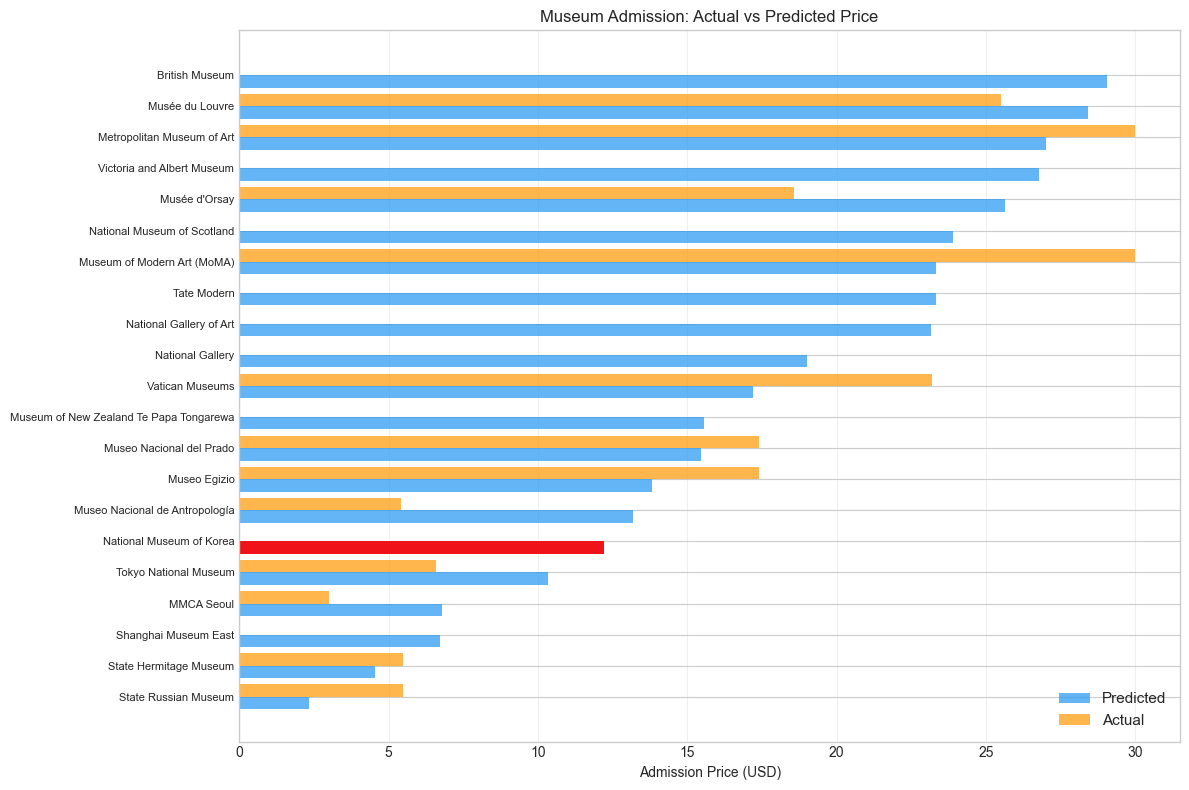

In [14]:
# 실제 vs 예측 입장료 시각화
plt.figure(figsize=(12, 8))
df_sorted = df.sort_values('predicted_price_usd', ascending=True)
y_pos = range(len(df_sorted))

plt.barh(y_pos, df_sorted['predicted_price_usd'], height=0.4, align='edge',
         color='#2196F3', alpha=0.7, label='Predicted')
plt.barh([y + 0.4 for y in y_pos], df_sorted['adult_price_local_usd'], height=0.4,
         align='edge', color='#FF9800', alpha=0.7, label='Actual')

# 국립중앙박물관 강조
nmk_idx = list(df_sorted['museum']).index('National Museum of Korea')
plt.barh(nmk_idx, df_sorted.iloc[nmk_idx]['predicted_price_usd'],
         height=0.4, align='edge', color='red', alpha=0.9)

plt.yticks([y + 0.4 for y in y_pos], df_sorted['museum'], fontsize=8)
plt.xlabel('Admission Price (USD)')
plt.title('Museum Admission: Actual vs Predicted Price')
plt.legend(fontsize=11)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}figures/regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 국립중앙박물관 종합 가격 추정

In [15]:
KRW_PER_USD = 1472  # 2026.03.10 기준 환율

nmk = df[df['museum'] == 'National Museum of Korea'].iloc[0]

# 방법 1: 회귀분석
pred_price = nmk['predicted_price_usd']

# 방법 2: 같은 클러스터 벤치마크
c_paid = df[(df['cluster'] == nmk['cluster']) & (df['adult_price_local_usd'] > 0)]
cluster_avg = c_paid['adult_price_local_usd'].mean()
cluster_med = c_paid['adult_price_local_usd'].median()


print('=' * 55)
print('  국립중앙박물관 최적 입장료 종합 추정')
print('=' * 55)
print(f'\n  방법 1) 회귀분석 예측가')
print(f'    ${pred_price:.2f} (₩{pred_price * KRW_PER_USD:,.0f})')
print(f'\n  방법 2) 같은 클러스터 유료박물관')
print(f'    평균: ${cluster_avg:.1f} (₩{cluster_avg * KRW_PER_USD:,.0f})')
print(f'    중간값: ${cluster_med:.1f} (₩{cluster_med * KRW_PER_USD:,.0f})')


  국립중앙박물관 최적 입장료 종합 추정

  방법 1) 회귀분석 예측가
    $12.20 (₩17,958)

  방법 2) 같은 클러스터 유료박물관
    평균: $8.7 (₩12,779)
    중간값: $5.5 (₩8,096)


## 5. 결과 저장

In [16]:
# Tableau / 추후 분석용 CSV 저장
output_cols = [
    'museum', 'city', 'cluster',
    'total_area_sqm', 'collection_size', 'visitors_latest',
    'adult_price_local_usd', 'predicted_price_usd',
    'city_gdp_per_capita', 'big_mac_index',
    'admission_free_yn', 'has_dual_pricing',
    'latitude', 'longitude',
    'pca1', 'pca2'
]
output_cols = [c for c in output_cols if c in df.columns]

df[output_cols].to_csv(f'{OUTPUT_DIR}analysis_result.csv', index=False)
print('✅ analysis_result.csv 저장 완료')
print(f'\n저장된 컬럼: {output_cols}')

✅ analysis_result.csv 저장 완료

저장된 컬럼: ['museum', 'city', 'cluster', 'total_area_sqm', 'collection_size', 'visitors_latest', 'adult_price_local_usd', 'predicted_price_usd', 'city_gdp_per_capita', 'big_mac_index', 'admission_free_yn', 'has_dual_pricing', 'latitude', 'longitude', 'pca1', 'pca2']
